In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

performance = pd.read_csv("dim_performance.csv")

In [7]:
performance.isnull().sum()

PerfKey          0
TripID           0
OTPFlag          0
DelayAnalysis    0
AverageSpeed     0
IdleDuration     0
BrakeEvents      0
dtype: int64

In [8]:
performance.duplicated().sum()

np.int64(0)

In [9]:
performance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PerfKey        20000 non-null  int64  
 1   TripID         20000 non-null  object 
 2   OTPFlag        20000 non-null  object 
 3   DelayAnalysis  20000 non-null  int64  
 4   AverageSpeed   20000 non-null  float64
 5   IdleDuration   20000 non-null  int64  
 6   BrakeEvents    20000 non-null  int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 1.1+ MB


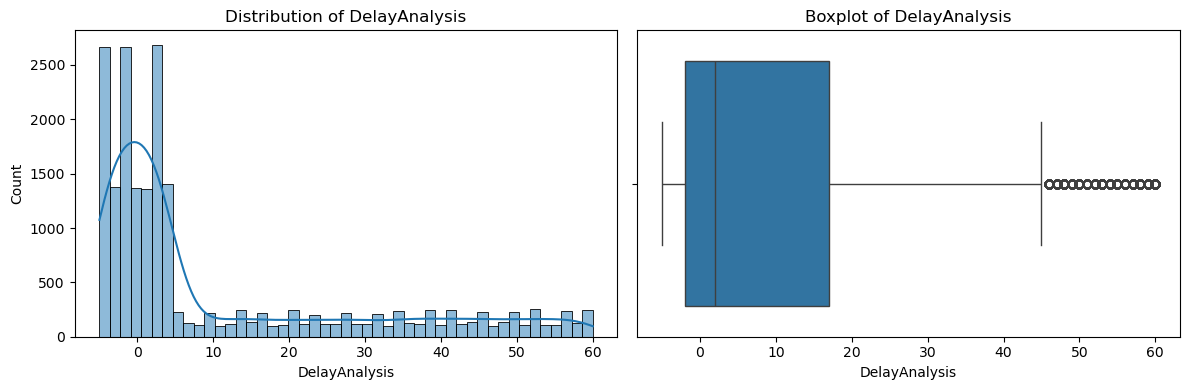

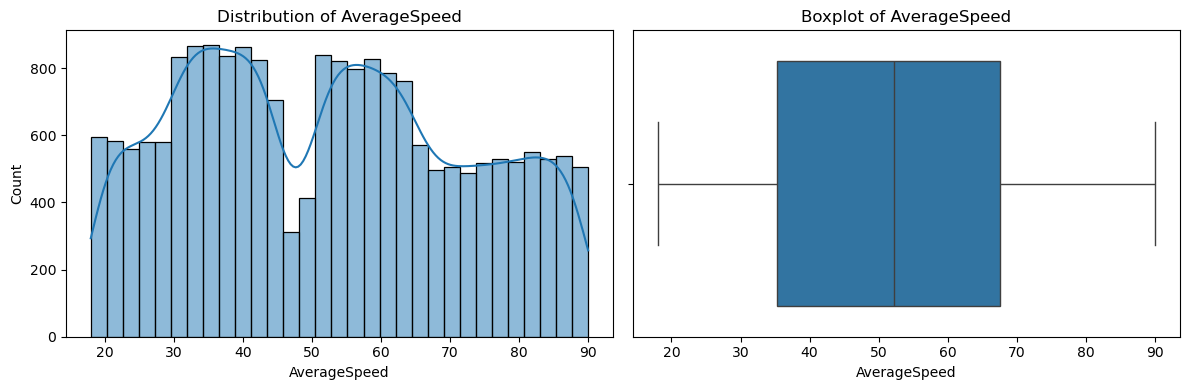

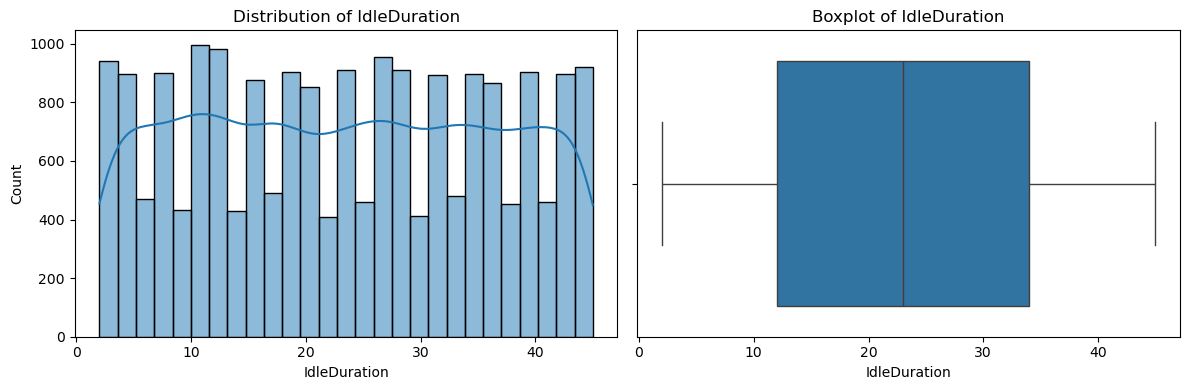

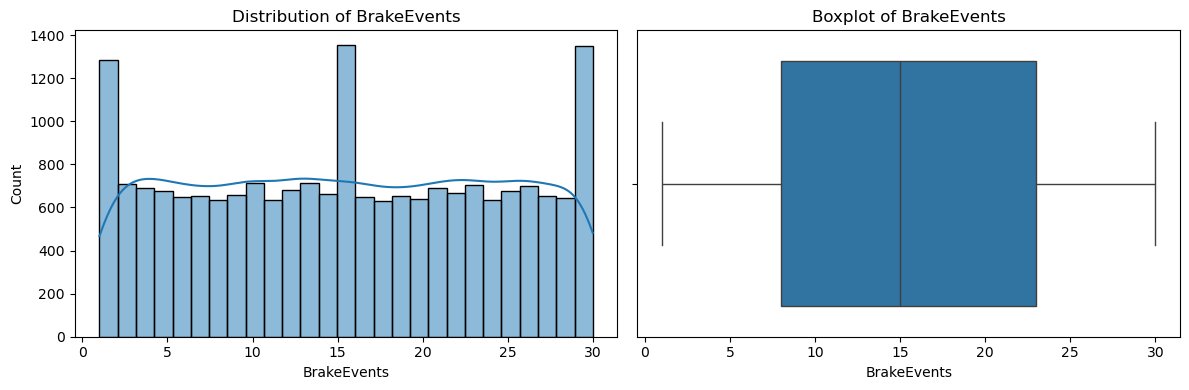

In [10]:
num_cols = [
    'DelayAnalysis',
    'AverageSpeed',
    'IdleDuration',
    'BrakeEvents'
]

for col in num_cols:

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    sns.histplot(performance[col], kde=True)
    plt.title(f'Distribution of {col}')

    plt.subplot(1,2,2)
    sns.boxplot(x=performance[col])
    plt.title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

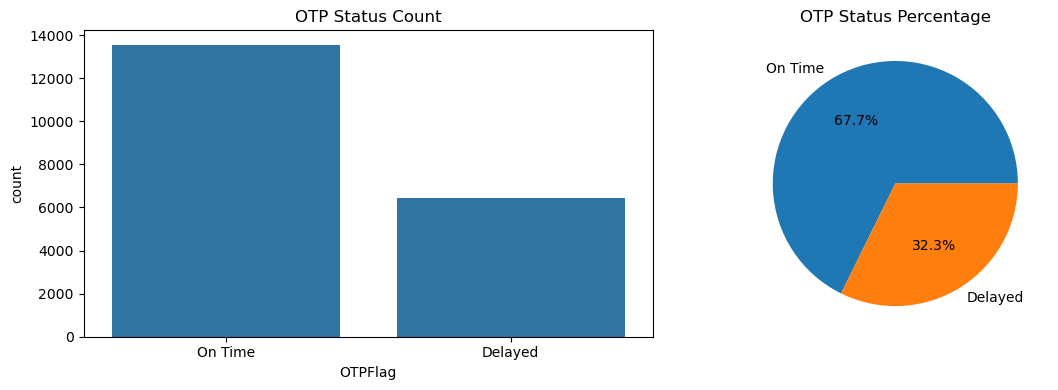

In [11]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)

sns.countplot(
    x='OTPFlag',
    data=performance
)

plt.title('OTP Status Count')

plt.subplot(1,2,2)

performance['OTPFlag'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title('OTP Status Percentage')

plt.tight_layout()
plt.show()

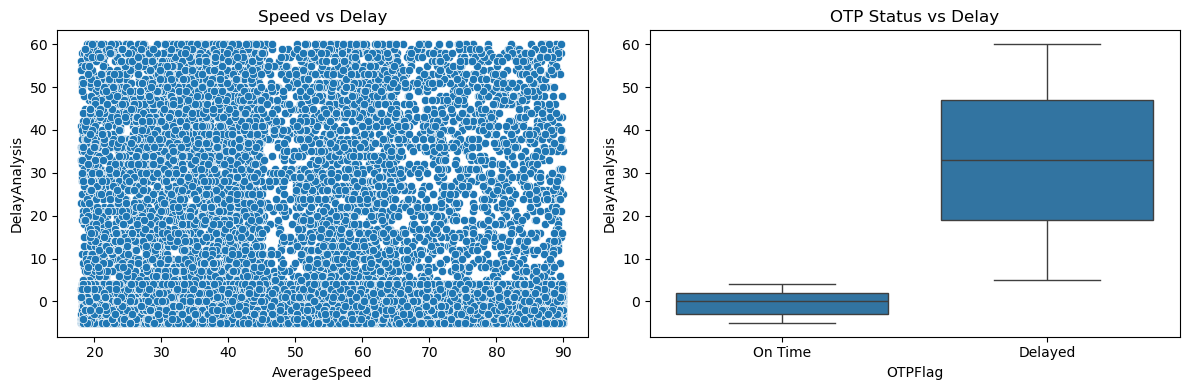

In [12]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)

sns.scatterplot(
    x='AverageSpeed',
    y='DelayAnalysis',
    data=performance
)

plt.title('Speed vs Delay')

plt.subplot(1,2,2)

sns.boxplot(
    x='OTPFlag',
    y='DelayAnalysis',
    data=performance
)

plt.title('OTP Status vs Delay')

plt.tight_layout()
plt.show()

In [13]:
perf_num = performance[
    [
        'DelayAnalysis',
        'AverageSpeed',
        'IdleDuration',
        'BrakeEvents'
    ]
]

corr = perf_num.corr()

corr

,DelayAnalysis,AverageSpeed,IdleDuration,BrakeEvents
DelayAnalysis,1.000000,-0.129015,0.001031,0.012904
AverageSpeed,-0.129015,1.000000,-0.001184,-0.005362
IdleDuration,0.001031,-0.001184,1.000000,-0.002195
BrakeEvents,0.012904,-0.005362,-0.002195,1.000000


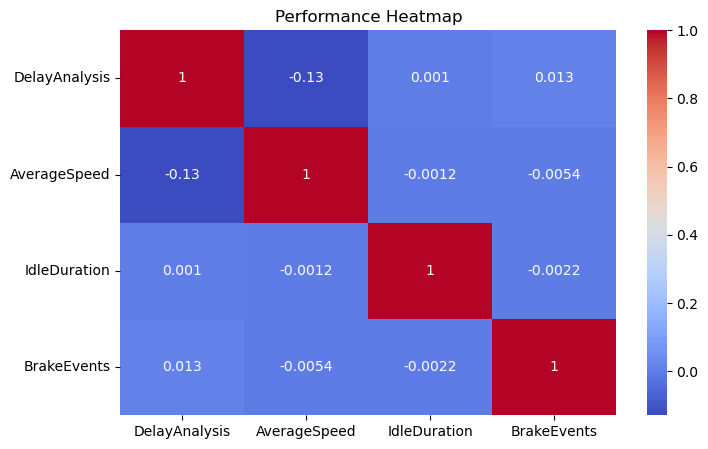

In [14]:
plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Performance Heatmap')
plt.show()

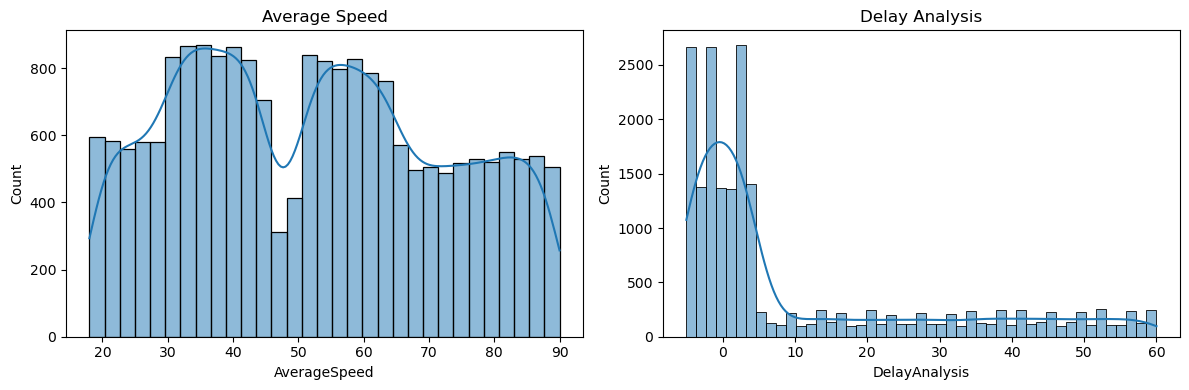

In [15]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.histplot(
    performance['AverageSpeed'],
    kde=True
)
plt.title('Average Speed')

plt.subplot(1,2,2)
sns.histplot(
    performance['DelayAnalysis'],
    kde=True
)
plt.title('Delay Analysis')

plt.tight_layout()
plt.show()